# Set-up (!)

In [ ]:
# Load dataset
diabetes <- read.csv("diabetes.csv")

# K-means (!)

In [ ]:
# Apply K-means to ENTIRE Dataset (minus Outcome)
X <- diabetes[, names(diabetes) != "Outcome"]
X_scaled <- scale(X)

set.seed(123)
k4 <- kmeans(X_scaled,
             centers = 4,
             nstart = 25)

diabetes$Cluster <- as.factor(k4$cluster)

# Scatterplots (K-means) (!)

In [ ]:
install.packages("ggplot2")
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Scatterplot (Outcome vs Clusters)
  # use PCA to reduce the data to 2 dimensions
pca <- prcomp(X_scaled)

plot_data <- data.frame(
  PC1 = pca$x[,1],
  PC2 = pca$x[,2],
  Outcome = as.factor(diabetes$Outcome),
  Cluster = diabetes$Cluster
)

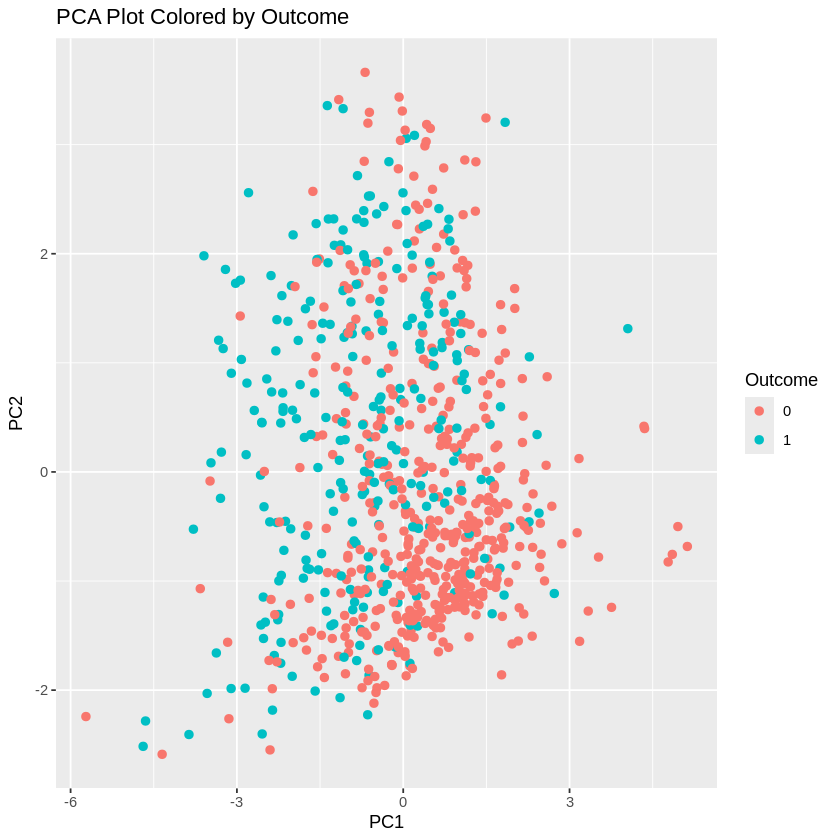

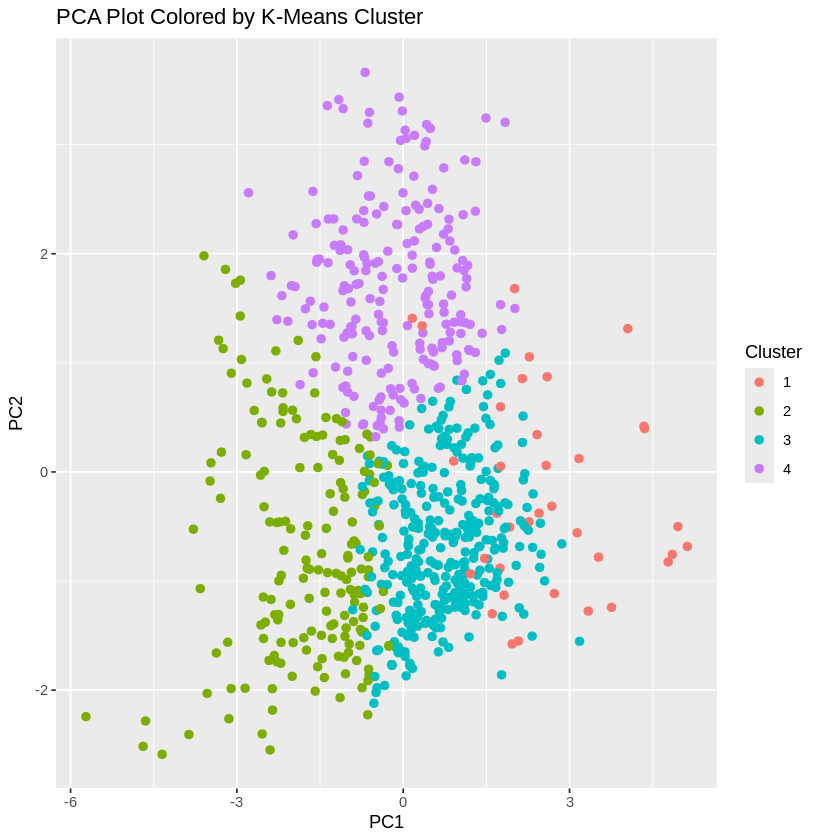

In [ ]:
# Plot by Outcome
ggplot(plot_data,
       aes(x = PC1,
           y = PC2,
           color = Outcome)) +
  geom_point(size = 2) +
  labs(title = "PCA Plot Colored by Outcome")

# Plot by Cluster
ggplot(plot_data,
       aes(x = PC1,
           y = PC2,
           color = Cluster)) +
  geom_point(size = 2) +
  labs(title = "PCA Plot Colored by K-Means Cluster")

# Split Train/Test (!)

In [ ]:
set.seed(123)

split <- sample(
  seq_len(nrow(diabetes)),
  size = 0.8 * nrow(diabetes)
)

train <- diabetes[split, ]
test <- diabetes[-split, ]

    Fit K-means

In [ ]:
# Remove Outcome & Cluster
X_train <- train[, !(names(train) %in% c("Outcome", "Cluster"))]
X_test <- test[, !(names(test) %in% c("Outcome", "Cluster"))]

# Scale
X_train_scaled <- scale(X_train)
X_test_scaled <- scale(X_test, center = attr(X_train_scaled, "scaled:center"), scale = attr(X_train_scaled, "scaled:scale"))

# Fit K-means
set.seed(123)
k4_train <- kmeans(X_train_scaled, centers = 4, nstart = 25)

# Assign Clusters
train$Cluster <- as.factor(k4_train$cluster)
test$Cluster <- as.factor(
  apply(
    X_test_scaled,
    1,
    function(x)
      which.min(
        colSums(
          (t(k4_train$centers) - x)^2
        )
      )
  )
)

# Logistic Regression

In [ ]:
model_kmeans <- glm(Outcome ~ Cluster, data = train, family = binomial)

In [ ]:
# Predict
prob <- predict(model_kmeans, newdata = test, type = "response")
pred <- ifelse(prob > 0.5, 1, 0)

mean(pred == test$Outcome)
table(pred, test$Outcome)

# Elbow Method (K-means)

In [ ]:
wcss <- numeric(10)

for (i in 1:10) {
  wcss[i] <- kmeans(
    X_scaled,
    centers = i,
    nstart = 25
  )$tot.withinss
}

plot(
  1:10,
  wcss,
  type = "b",
  pch = 19,
  xlab = "Number of Clusters (K)",
  ylab = "WCSS",
  main = "Elbow Method"
)

# Elbow Method (KNN)